# Машинное обучение
# Семинар 8
# Тензоры, MLP

Всем привет! Сегодня мы обсудим введение в DL.

Перед тем, как начать семинар, давайте вкратце обсудим, на каких устройствах и почему мы считаем наши вычисления нейронных сетей.




1. **GPU** (графические процессоры) — основная рабочая лошадка современного машинного обучения. GPU содержат тысячи простых ядер, идеально подходящих для параллельных матричных операций, составляющих основу нейросетевых вычислений. Важно выделить два главных конкурента на рынке:

    1.1. **CUDA** NVIDIA доминирует в этой сфере с линейкой A100, H100, RTX 4090. Архитектуры Hopper и Ada Lovelace обеспечивают до 989 TOPS для ИИ-вычислений. Платформа CUDA имеет зрелую экосистему библиотек (cuDNN, cuBLAS), широкую поддержку фреймворков и оптимизированные драйверы, что делает NVIDIA стандартом индустрии (90% всех вычислений на видеокарточках NVIDIA) [1](https://developer.nvidia.com/cuda-toolkit), [2](https://github.com/NVIDIA/CUDALibrarySamples), [3](https://en.wikipedia.org/wiki/CUDA).

    1.2. **ROCm** AMD предлагает открытую альтернативу CUDA с картами MI300X, RX 7900 XTX. Поддерживает PyTorch, TensorFlow и JAX через HIP API. Преимущества: открытый исходный код, конкурентная цена, поддержка Linux. Но пока что меньшая экосистема библиотек, ограниченная совместимость с некоторыми фреймворками, много багов [1](https://www.amd.com/en/products/software/rocm.html), [2](https://github.com/ROCm/ROCm), [3](https://en.wikipedia.org/wiki/ROCm).

2. **TPU** от Google — тензорные процессоры, специально разработанные для нейросетевых вычислений. TPU v5 обеспечивает до 459 TOPS при энергопотреблении 200W. Оптимизированы для матричных операций, поддерживают bfloat16, интегрированы с TensorFlow/JAX. Доступны только через Google Cloud/Colab и работают в полную силу только на JAX [1](https://en.wikipedia.org/wiki/Tensor_Processing_Unit), [2](https://cloud.google.com/tpu).

3. **NPU** Huawei Ascend — китайская альтернатива западным решениям (+5 социального рейтинга от партии). Ascend 910B предлагает до 256 TOPS FP16, поддерживает MindSpore фреймворк. Особенности: собственная архитектура Da Vinci, оптимизация для китайского рынка, интеграция с облачными сервисами Huawei Cloud. Минусы такие же, как и у ROCm **AMD** [1](https://www.hiascend.com/en/), [2](https://gitee.com/ascend/pytorch).

4. **Metal** чипы от Apple (M-серия) — интегрированные процессоры с унифицированной памятью. Преимущества: энергоэффективность, бесшовная интеграция с macOS, оптимизированные Metal Performance Shaders. Поддержка CoreML, TensorFlow Lite. Ограничения: только экосистема Apple, возможно только что-то локальное запускать на инференс, обучать что-то серьезное не получится [1](https://developer.apple.com/metal/), [2](https://developer.apple.com/metal/pytorch/).
5. **CPU** используются для менее требовательных задач и вывода небольших моделей, но значительно медленнее GPU для обучения.

Почему считаем на видеокарточках? Нейросети требуют:

- Массовых параллельных вычислений (миллионы параметров обновляются одновременно).

- Интенсивных матричных операций (тензорные умножения, свертки).

- Оптимизированных операций с плавающей точкой.

Чтобы понять преимущество, посмотрите это [видео](https://www.youtube.com/watch?v=Ge-g3xZ5bb8).



Вы видели упоминание всяких FP16/BF16, операций с плавающией точкой и так далее, об этом поговорим чуть позже.

Давайте вкратце сначала обсудим про основные фреймворки в DL: `TensorFlow`, `JAX`, `Keras` и `Pytorch`.

## Фреймворки в DL

### TensorFlow


[TensorFlow](https://www.tensorflow.org) - один из самых известных фреймворков глубокого обучения, созданный Google Brain в 2015 году. Изначально он строился вокруг статических вычислительных графов, что позволяло эффективно оптимизировать и компилировать вычисления для масштабного обучения, особенно на GPU и TPU. Такая архитектура была мощной, но вызывала у исследователей затруднения: приходилось заранее описывать граф, что делало отладку и эксперименты менее гибкими.


С течением времени TensorFlow прошел эволюцию. Появилось Eager Execution (динамический режим, аналогичный PyTorch), а также множество надстроек, включая Keras как основной высокоуровневый API. TensorFlow развивается не только как библиотека для обучения моделей, но и как экосистема для продакшна. Здесь выделяются:

- TensorFlow Serving - система для развертывания и обслуживания моделей.

- TensorFlow Lite - инструментарий для оптимизации и запуска моделей на мобильных устройствах и микроконтроллерах.

- TensorFlow.js - запуск моделей прямо в браузере.

Главное преимущество, что есть поддержка TPU и сразу из коробки есть возможность развернуть на слабых устройствах.

TensorFlow постепенно уступил позиции PyTorch.

Основные причины: более сложный интерфейс в ранних версиях, медленное внедрение динамических графов и менее “питонический” стиль кода.

### JAX

[JAX](https://github.com/jax-ml/jax) - относительно новый инструмент от Google Research, который позиционируется не столько как полноценный фреймворк для нейросетей, сколько как библиотека для ускоренных численных вычислений и автоматического дифференцирования. По сути, JAX объединяет возможности NumPy, автоматического дифференцирования (autograd) и компиляции XLA, что делает его мощным инструментом для научных исследований.

Основные идеи JAX заключаются в нескольких ключевых трансформациях:

`grad` - автоматическое вычисление градиентов.

`jit` - Just-In-Time компиляция, позволяющая ускорить выполнение кода за счёт оптимизации и компиляции под XLA.

`vmap` - векторизация, позволяющая автоматически параллелить вычисления по батчам данных.

`pmap` - распределённое выполнение на множестве устройств (GPU/TPU).

Важно, что JAX по философии ближе к функциональному программированию: в отличие от PyTorch и TensorFlow, которые живут по объектно-ориентированные паттернам, JAX требует работы с чистыми функциями и трансформациями.

Поверх JAX развилась экосистема:

1. [Flax](https://github.com/google/flax) - гибкая библиотека для нейросетей.

2. [Haiku](https://github.com/google-deepmind/dm-haiku) (DeepMind) - более модульный подход.

3. [Optax](https://github.com/google-deepmind/optax) - набор оптимизаторов.

4. [RLax](https://github.com/google-deepmind/rlax) - компоненты для обучения с подкреплением.

Преимущество JAX - очень высокая производительность и гибкость. Его можно ценить за возможность быстро экспериментировать со сложной математикой (например, PDE-решатели или физически-информированные нейросети) и при этом масштабироваться на TPU-кластеры.

Недостаток JAX - это ещё относительно «молодая» экосистема. Нет такого количества готовых моделей и обучающих материалов, как у PyTorch. Кроме того, JAX требует более глубокого понимания программирования и функционального подхода, что повышает порог вхождения.

### Keras

[Keras](https://keras.io/) - это высокоуровневый API для глубокого обучения, изначально разработанный как независимая библиотека известным ученым [Франсуа Шолле](https://scholar.google.com/citations?user=VfYhf2wAAAAJ&hl=en), но позже интегрированный в TensorFlow. Сегодня Keras 3 (выпущенный в 2023 – 2024 годах) поддерживает мультибэкенд: работать можно не только с TensorFlow, но и с PyTorch и JAX.
По факту - это оболочка над 3-я фреймворками.

Главная идея Keras - простота и читаемость [!важно]. Даже на главной странице написано:

> *Keras is a deep learning API designed for human beings, not machines.*



В то время как TensorFlow и PyTorch требуют описывать детали графа или слоя, Keras предоставляет декларативный и понятный стиль:` model = Sequential([Dense(...), Activation(...)])`.

Но естественно простота несет за собой более ограниченный контроль по сравнению с «чистыми» фреймворками. И из-за этого практически нигде не используется, кроме как фреймворк для обучения работы с DL.

### PyTorch

[PyTorch](https://pytorch.org/) появился в 2017 году в FAIR как «питоничный» наследник Torch7 (Lua). Он сделал ставку на динамические вычислительные графы и автодифференцирование, что резко упростило исследовательскую работу. Благодаря простоте, гибкости и тесной интеграции с экосистемой Python он быстро стал стандартом в академии и индустрии, вытеснив статические графы эпохи TensorFlow 1.x.

Почему он крут и популярен:

- Удобство: естественный Python-API, простая отладка, контроль потока (if/for).
- Производительность: CUDA, AMP, `torch.compile` (2.x), профилировщик.
- Масштаб: DDP/FSDP, поддержка огромных моделей.
- Экосистема: torchvision/torchaudio/torchtext и стал основой для Hugging Face.
- Продакшн: TorchServe, ONNX/TensorRT, C++ libtorch.
- Сообщество: тысячи туториалов, быстрый выпуск фич, удобство интегрирования свое.

Ключевые преимущества: динамический граф + удобство Python → быстрые исследования и надёжный продакшн.

### Сравнительная таблица

| Фреймворк      | Основная идея             | Сильные стороны                                   | Слабые стороны                           | Основные сферы применения |
|----------------|---------------------------|--------------------------------------------------|------------------------------------------|---------------------------|
| **TensorFlow** | Статический/динамический граф | Продакшн-инструменты, поддержка TPU, кросс-платформенность | Сложнее для исследований, менее питоничный | Поддержание старых решений, мобильные/веб-решения |
| **JAX**        | Функциональный стиль, XLA, автодиф | Высокая производительность, гибкость, TPU-кластеризация | Молодая экосистема, высокий порог входа   | Cutting-edge исследования, математика, физика |
| **Keras**      | Высокоуровневый API        | Простота, мультибэкенд, быстрые прототипы        | Ограниченный контроль, меньше гибкости   | Обучение, быстрый старт, учебные курсы |
| **PyTorch**    | Динамический граф          | Простота, гибкость, огромное сообщество, продакшн-инструменты | Ранее слабый деплой, но за счет сообщества щас все норм | Промышленный деплой, исследования, индустрия, курсы |


## Torch

### Установка PyTorch

In [1]:
# !pip install torch

См. [здесь](https://pytorch.org/get-started/locally/), как установить PyTorch с поддержкой GPU для различных операционных систем.



### Активируем GPU (если в колабе)

По шагам:

1. Нажимаем "Среда выполнения" (сверху на панели).
2. Нажимаем "Сменить среду выполнения".
3. Выбираем Графический процессор T4.

In [2]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


### Проверяем, что все работает

In [3]:
import torch
print("Версия torch:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

Версия torch: 2.8.0
Устройство: cpu


### Вспомогательные функции

In [4]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np
import time
torch.manual_seed(0)

In [5]:
def plot_live(epoch, model, x_train, y_train, x_val, y_val, x_all, y_true_all,
              train_losses, val_losses):
    '''
    Функция для графиков обучения модели, которая тестируется внутри самой функции
    Args:
        epoch - номер эпохи для графиков
        model - сама нейросеть, наследует классу torch.nn.Module
        x_train, y_train - обучающая выборка, тензоры
        x_val, y_val - валидационная выборка, тензоры
    '''
    clear_output(wait=True)

    # Лоссы
    plt.figure(figsize=(6,4))
    plt.plot(train_losses, label="train MSE")
    plt.plot(val_losses, label="val MSE")
    plt.xlabel("epoch"); plt.ylabel("loss (MSE)")
    plt.title(f"Learning curves (epoch {epoch})")
    plt.legend(); plt.grid(True)
    display(plt.gcf())
    plt.close()

    # Предсказания
    model.eval()  # переводим модель в режим evaluation - некоторые слои в нейросетях по-разному работают на train & val
    with torch.no_grad():  # функция, выключающая подсчет каких-либо градиентов - все-таки мы на eval режиме
        y_pred_all = model(x_all)  # model(x) - запуск метода model.forward(x) ~ model.predict из sklearn
        y_pred_all = y_pred_all.cpu().numpy()  # 1) переводим тензор на cpu 2) переводим тензор в np.array 
        
    x_cpu = x_all.cpu().numpy()
    y_true_cpu = y_true_all.cpu().numpy()

    order = np.argsort(x_cpu[:,0])

    plt.figure(figsize=(7,4))
    plt.scatter(x_train.cpu().numpy(), y_train.cpu().numpy(), s=10, alpha=0.35, label="train noisy")
    plt.scatter(x_val.cpu().numpy(), y_val.cpu().numpy(), s=10, alpha=0.35, label="val noisy")
    plt.plot(x_cpu[order], y_true_cpu[order], linewidth=2, label="true sin(x)")
    plt.plot(x_cpu[order], y_pred_all[order], linewidth=2, label=f"prediction @ {epoch}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title("Model prediction vs ground truth")
    plt.legend(); plt.grid(True)
    display(plt.gcf())
    plt.close()

In [45]:
def rosenbrock(w, a=1.0, b=100.0):
    x, y = w[0], w[1]
    return (a - x)**2 + b*(y - x**2)**2


def make_optimizer(params, name: str, **kwargs):
    name = name.lower()
    if name == "sgd":
        return torch.optim.SGD(params,
            lr=kwargs.get("lr", 5e-4),
            momentum=kwargs.get("momentum", 0.9),
            weight_decay=kwargs.get("weight_decay", 0.0),
            nesterov=kwargs.get("nesterov", False))
    if name == "adam":
        return torch.optim.Adam(params,
            lr=kwargs.get("lr", 2e-3),
            betas=kwargs.get("betas", (0.9, 0.999)),
            eps=kwargs.get("eps", 1e-8),
            weight_decay=kwargs.get("weight_decay", 0.0))
    if name == "lbfgs":
        return torch.optim.LBFGS(params,
            lr=kwargs.get("lr", 1.0),
            max_iter=kwargs.get("max_iter", 10),
            history_size=kwargs.get("history_size", 10),
            line_search_fn=kwargs.get("line_search_fn", "strong_wolfe"))
    raise ValueError(f"Unknown optimizer: {name}")


def plot_live_optim(step, path, losses, grad_norms, xx, yy, zz, title):
    clear_output(wait=True)

    plt.figure(figsize=(6,5))
    plt.contour(xx, yy, zz, levels=25)
    P = np.array(path)
    if len(P) > 1:
        plt.plot(P[:,0], P[:,1], marker="o", markersize=2, linewidth=1)
    plt.title(f"{title} — step {step}")
    plt.xlabel("x"); plt.ylabel("y")
    display(plt.gcf()); plt.close()

    plt.figure(figsize=(7,3.5))
    plt.plot(losses, label="loss")
    plt.plot(grad_norms, label="||grad||")
    plt.xlabel("step"); plt.title("Loss & gradient norm")
    plt.legend(); plt.grid(True)
    display(plt.gcf()); plt.close()


def run_live_optim(opt_name="sgd", steps=300, plot_every=10, start=(-1.5, 2.0), **opt_kwargs):
    x_min,x_max,y_min,y_max = -2.0,2.0,-1.0,3.0
    xx,yy = np.meshgrid(np.linspace(x_min,x_max,180), np.linspace(y_min,y_max,180))
    zz = (1-xx)**2 + 100.0*(yy-xx**2)**2

    w = torch.tensor(start, dtype=torch.float32, requires_grad=True)
    opt = make_optimizer([w], opt_name, **opt_kwargs)
    path, losses, grad_norms = [], [], []

    def closure():
        opt.zero_grad(); loss = rosenbrock(w); loss.backward(); return loss

    for t in range(1, steps+1):
        if opt_name.lower() == "lbfgs":
            loss = opt.step(closure)
            loss_val = loss.item() if hasattr(loss, "item") else float(loss)
        else:
            opt.zero_grad(); loss = rosenbrock(w); loss.backward(); opt.step()
            loss_val = float(loss.detach())

        with torch.no_grad():
            gnorm = float(w.grad.norm()) if w.grad is not None else float("nan")
        path.append(w.detach().numpy().copy())
        losses.append(loss_val); grad_norms.append(gnorm)

        if t % plot_every == 0 or t == 1 or t == steps:
            plot_live_optim(t, path, losses, grad_norms, xx, yy, zz, f"{opt_name.upper()} on Rosenbrock")

    return np.array(path), np.array(losses), np.array(grad_norms), w.detach().numpy()

## Основные объекты в PyTorch

Познакомимся с основными объектами в PyTorch:

- **Тензоры (torch.Tensor)**: многомерные массивы с dtype/device, могут хранить градиенты (requires_grad=True).


- **Автодифференцирование (autograd)**: автоматически строит вычислительный граф и считает градиенты.

- **Модули (torch.nn.Module)**: слои и модели; обучаемые веса — это nn.Parameter.

- **Оптимизаторы (torch.optim)**: SGD, Adam и др.; получают параметры модели и обновляют их через step()/zero_grad().

- **torch.nn**: например, Dropout, MSELoss — блоки PyTorch.

- **Данные**: Dataset, DataLoader (параллельная загрузка, батчи), Sampler; трансформации/аугментации (часто из torchvision.transforms).

- **Полезные режимы/утилиты**: model.train()/eval(), torch.no_grad(), функциональный API torch.nn.functional, управление устройством (cpu/cuda).

## Тензоры

## Что такое `torch.Tensor`?

<img src="https://drive.google.com/uc?export=view&id=1Ona80D87Z_bR5GsCIZUk_JxFIdvF4s6M" alt="Тензор_мем" width="600"/>

В библиотеке PyTorch базовым строительным блоком является объект тензор - [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html).

> Тензор в PyTorch - это многомерный массив, очень похожий на NumPy array, но с дополнительными возможностями:

- поддержка вычислений на GPU (CUDA, ROCm, Metal),
- автоматическое дифференцирование (через autograd),
- интеграция в глубокие нейронные сети и оптимизационные задачи.

Если упростить:

- **скаляр** - число (тензор нулевой размерности),
- **вектор** - одномерный массив (тензор размерности 1),
- **матрица** - двумерный массив (тензор размерности 2),
- **тензор** - обобщение на $n$ измерений.

### Создание тензоров

Тензоры можно создавать разными способами:

Из Python-списка или массива (вектор)

In [7]:
print(torch.Tensor([1, 2, 3, 4.5])) # 1D вектор
print(torch.Tensor([[1, 2, 3], [4, 5, 6]])) # 2D матрица

tensor([1.0000, 2.0000, 3.0000, 4.5000])
tensor([[1., 2., 3.],
        [4., 5., 6.]])


Создать матрицу из NumPy массива:

In [8]:
import numpy as np

np_array = np.array([[1, 2, 3], [4, 5, 6]])
torch_tensor = torch.from_numpy(np_array)
print(torch_tensor)


tensor([[1, 2, 3],
        [4, 5, 6]])


Создать случайную матрицу:

In [9]:
print(f"Равномерное распределение [0, 1):\n {torch.rand(2, 3)}")
print(f"Нормальное распределение:\n {torch.randn(2, 3)}")

Равномерное распределение [0, 1):
 tensor([[0.4963, 0.7682, 0.0885],
        [0.1320, 0.3074, 0.6341]])
Нормальное распределение:
 tensor([[ 1.2645, -0.6874,  0.1604],
        [-0.6065, -0.7831,  1.0622]])


Создать специальный тензор:

In [10]:
print(f"Матрица из нулей:\n {torch.zeros(3, 3)}")
print(f"Матрица из единиц:\n {torch.ones(2, 2)}")
print(f"Единичная матрица:\n {torch.eye(4)}")
print(f"Тензор чисел от 0 до 9 включительно:\n {torch.arange(0, 10, 2)}")
print(f"Тензор чисел от 0 до 1 с шагом 0.25:\n {torch.linspace(0, 1, 5)}")  # [0., 0.25, 0.5, 0.75, 1.]

Матрица из нулей:
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
Матрица из единиц:
 tensor([[1., 1.],
        [1., 1.]])
Единичная матрица:
 tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])
Тензор чисел от 0 до 9 включительно:
 tensor([0, 2, 4, 6, 8])
Тензор чисел от 0 до 1 с шагом 0.25:
 tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


### Атрибуты тензоров

In [11]:
x = torch.Tensor([[1, 2, 3], [4, 5, 6]])

print(f"{x.shape} → форма aka шейп ака размерность")
print(f"{x.ndim} → количество измерений")
print(f"{x.size(0)} → размер по оси 0")
print(f"{x.size(1)} → размер по оси 1")
print(f"{x.dtype} → тип данных тензора")
print(f"{x.device} → устройство, где лежит тензор")
print(f"{x.requires_grad} → требует градиент")


torch.Size([2, 3]) → форма aka шейп ака размерность
2 → количество измерений
2 → размер по оси 0
3 → размер по оси 1
torch.float32 → тип данных тензора
cpu → устройство, где лежит тензор
False → требует градиент


### Типы данных (`dtype`)

Тип данных - это формальное описание того, какие значения может хранить переменная и какие операции над ней допустимы. Типы данных позволяют компьютеру корректно интерпретировать двоичное представление информации. Например, набор бит 01000001 может означать число 65 в десятичной системе, а может обозначать символ 'A' в кодировке ASCII.

Таким образом, `dtype` определяет:

1. Вид значения — целое, вещественное, булево и т.п.

2. Разрядность (8, 16, 32, 64 бит), которая влияет на диапазон возможных значений, точность и объём памяти.

PyTorch [поддерживает разные типы данных](https://docs.pytorch.org/docs/stable/tensors.html):

<!-- - **Целые числа:**  
  `torch.int8`, `torch.int16`, `torch.int32`, `torch.int64`

- **Вещественные числа:**  
  `torch.float16`, `torch.float32`, `torch.float64`

- **Булевы:**  
  `torch.bool`

- **Комплексные:**  
  `torch.complex64`, `torch.complex128`

**По умолчанию:**
- для целых — `torch.int64`
- для вещественных — `torch.float32` -->

| dtype                      | Диапазон значений                                  | Где применяется                                                         |
| -------------------------- | -------------------------------------------------- | ----------------------------------------------------------------------- |
| **torch.uint8**            | 0 … 255                                            | Маски, изображения в формате byte (0–255 пиксели)                       |
| **torch.int8**             | –128 … 127                                         | Квантованные модели, экономия памяти                                    |
| **torch.int16**            | –32 768 … 32 767                                   | Редко используется, промежуточный тип                                   |
| **torch.int32**            | –2 147 483 648 … 2 147 483 647                     | Индексы, работа с табличными данными                                    |
| **torch.int64**            | –9.22e18 … 9.22e18                                 | Индексы тензоров, метки классов (стандарт в PyTorch)                    |
| **torch.float16 (Half)**   | \~ ±6.5e4, точность \~3 знака                      | Обучение на GPU (Mixed Precision), ускорение вычислений                 |
| **torch.bfloat16**         | \~ ±3.4e38, точность \~3 знака (короткая мантисса) | Обучение на современных GPU/TPU, баланс между скоростью и стабильностью |
| **torch.float32 (Float)**  | \~ ±3.4e38, точность \~7 знаков                    | Основной тип для обучения нейросетей (default)                          |
| **torch.float64 (Double)** | \~ ±1.8e308, точность \~15 знаков                  | Научные вычисления, когда нужна высокая точность                        |
| **torch.bool**             | True / False                                       | Логические маски, фильтрация элементов                                  |
| **torch.complex64**        | Два float32 (вещественная + мнимая часть)          | Сигнальная обработка, квантовая физика                                  |
| **torch.complex128**       | Два float64                                        | Высокоточные комплексные вычисления                                     |

---


![Чиселки](https://sungminlee0810.github.io/assets/images/2021_0224/image1.png)

Мы не всегда используем `float16`, потому что этот формат слишком ограничен по диапазону и точности, что часто делает обучение нейросетей нестабильным.  

- В реальных вычислениях (например, при экспоненте в softmax) встречаются гораздо большие числа. Это приводит к **переполнению (overflow)**, когда значения превращаются в `inf`, или наоборот - к **обнулению (underflow)** для очень маленьких чисел.  
- Градиенты в обучении часто бывают очень малыми $(10^{-6}$, $10^{-8})$, и в `float16` они просто исчезают, становясь нулями.  

Поэтому `float16` применяют в основном в режиме **mixed precision** (смешанная точность): часть операций и веса в `float16`, но накопление градиентов и критические вычисления остаются в `float32`. Это позволяет использовать преимущества FP16 (меньше памяти и быстрее на GPU с Tensor Cores) без потери стабильности.  

---

Мы практически никогда не используем **float64** (double precision), потому что:  

- он требует **в 2 раза больше памяти**,  
- выполняется значительно медленнее на GPU (многие ускорители сильно ограничены по FP64-производительности),  
- в 99% задач машинного обучения такой точности просто не требуется.  
- [в 1% задач](https://arxiv.org/html/2505.10949v1).  

---

В итоге, **основной рабочий формат в нейросетях - `float32` (`FP32`)**.  

- `FP32` - это "золотой стандарт": именно в нём PyTorch по умолчанию создает тензоры и обучает модели.  Он обеспечивает баланс между скоростью, точностью и стабильностью.


In [12]:
a = torch.tensor([1, 2, 3], dtype=torch.int32)
b = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)

print(a.dtype)  # torch.int32
print(b.dtype)  # torch.float32

#

torch.int32
torch.float32


> **Важно!**, чтобы все данные имели один и тот же тип, иначе это может привести к неожиданным ошибкам.

### Преобразования тензоров

In [13]:
A = torch.rand(2, 6)
print(A)

tensor([[0.1610, 0.2823, 0.6816, 0.9152, 0.3971, 0.8742],
        [0.4194, 0.5529, 0.9527, 0.0362, 0.1852, 0.3734]])


Превратить тензор в одномерный массив:

In [14]:
print(A.flatten())
print(A.reshape(-1))

tensor([0.1610, 0.2823, 0.6816, 0.9152, 0.3971, 0.8742, 0.4194, 0.5529, 0.9527,
        0.0362, 0.1852, 0.3734])
tensor([0.1610, 0.2823, 0.6816, 0.9152, 0.3971, 0.8742, 0.4194, 0.5529, 0.9527,
        0.0362, 0.1852, 0.3734])


Транспонировать матрицу:

In [15]:
print(A.T)

tensor([[0.1610, 0.4194],
        [0.2823, 0.5529],
        [0.6816, 0.9527],
        [0.9152, 0.0362],
        [0.3971, 0.1852],
        [0.8742, 0.3734]])


Для тензоров более высокой размерности нужно указать, какие измерения переставить.

In [16]:
print(A.transpose(0, 1))

tensor([[0.1610, 0.4194],
        [0.2823, 0.5529],
        [0.6816, 0.9527],
        [0.9152, 0.0362],
        [0.3971, 0.1852],
        [0.8742, 0.3734]])


#### **Важно!**

Допустим, у нас есть батч изображений в формате **NCHW** (batch, height, width, channels), как часто бывает при загрузке из NumPy/PIL:

In [17]:
# batch=32, высота=64, ширина=64, каналов=3
x = torch.randn(32, 64, 64, 3)
print(x.shape)  # torch.Size([32, 64, 64, 3])

torch.Size([32, 64, 64, 3])


PyTorch Conv2d ожидает данные в формате **NCHW** (batch, channels, height, width).

Здесь нельзя просто сделать `reshape(32, 3, 64, 64)`, потому что это перепутает данные: каналы не переместятся на нужную ось, а просто "нарежутся" из памяти.

Правильный способ:

In [18]:
x = x.permute(0, 3, 1, 2)  # (batch, channels, height, width)
print(x.shape)


torch.Size([32, 3, 64, 64])


Давайте взглянем более подробно:

In [19]:
a = torch.arange(12).reshape(3, 4)  # (3,4)
print(f"{a} \n")

# Хочется поменять местами оси: (4,3)
b = a.permute(1, 0)
print(f"{b} \n")


# Но если использовать reshape:
c = a.reshape(4, 3)
print(c)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]) 

tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]]) 

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])


Видно, что `reshape` не меняет оси, а просто "перекладывает" данные подряд.

А `permute` именно транспонирует.

Когда использовать `permute` и `reshape` в PyTorch.

| Задача | Пример входных данных | Что хотим | Правильный метод | Почему |
|--------|----------------------|-----------|------------------|--------|
| **Поменять порядок осей (транспонирование)** | `a.shape = (3, 4)` | `→ (4, 3)` | `a.permute(1, 0)` | Нужна перестановка измерений, `reshape` перепутает данные |
| **Изображения: NHWC → NCHW** | `(32, 64, 64, 3)` | `→ (32, 3, 64, 64)` | `x.permute(0, 3, 1, 2)` | `Conv2d` в PyTorch ждёт `(batch, channels, H, W)` |
| **Временные ряды: (batch, time, features) → (time, batch, features)** | `(16, 50, 128)` | `→ (50, 16, 128)` | `x.permute(1, 0, 2)` | `RNN/Transformer` часто требуют другой порядок |
| **Просто "сплющить" данные (flatten)** | `(32, 3, 64, 64)` | `→ (32, 12288)` | `x.reshape(32, -1)` | Оси не меняем, просто склеиваем |
| **Добавить размерность** | `(32, 128)` | `→ (32, 128, 1)` | `x.reshape(32, 128, 1)` | Новый размер без перестановки |
| **Разделить измерение на несколько** | `(32, 12288)` | `→ (32, 3, 64, 64)` | `x.reshape(32, 3, 64, 64)` | Данные уже в правильном порядке, надо только "распаковать" |
| **Транспонирование матриц в batch’е** | `(batch, M, N)` | `→ (batch, N, M)` | `x.permute(0, 2, 1)` | Транспонируем только последние две оси |

---
Правило здесь следующее:
- **`permute`** - когда меняем **оси** (их порядок).  
- **`reshape`** - когда меняем **форму** (размерности внутри осей), но их порядок остаётся.  


### Операции с тензорами одинаковой размерности

In [20]:
a = torch.Tensor([1, 2, 3]) # 1D вектор
b = torch.Tensor([-1, 0, 1]) # 1D вектор

A = torch.Tensor([[ 0, 1, 2], # 2D матрица
                  [-1, 0, 1]])
B = torch.Tensor([[1, 2, 3], # 2D матрица
                  [7, 0, 5]])
print(a)
print(b)
print(A)
print(B)

tensor([1., 2., 3.])
tensor([-1.,  0.,  1.])
tensor([[ 0.,  1.,  2.],
        [-1.,  0.,  1.]])
tensor([[1., 2., 3.],
        [7., 0., 5.]])


Покомпонентное сложение:

In [21]:
print("В случае 1D вектора:")
print(a + b) # 1D вектор
print("В случае 2D матрицы:")
print(A + B) # 2D матрица

В случае 1D вектора:
tensor([0., 2., 4.])
В случае 2D матрицы:
tensor([[1., 3., 5.],
        [6., 0., 6.]])


Покомпонентное умножение:

In [22]:
print("В случае 1D вектора:")
print(a * b) # 1D вектор

print("В случае 2D матрицы:")
print(A * B) # 2D матрица

В случае 1D вектора:
tensor([-1.,  0.,  3.])
В случае 2D матрицы:
tensor([[ 0.,  2.,  6.],
        [-7.,  0.,  5.]])


Покомпонентное возведение в степень:

In [23]:
print("В случае 1D вектора:")
print(a**b) # 1D вектор

print("В случае 2D матрицы:")
print(A ** B) # 2D матрица

В случае 1D вектора:
tensor([1., 1., 3.])
В случае 2D матрицы:
tensor([[ 0.,  1.,  8.],
        [-1.,  1.,  1.]])


Скалярное произведение:

In [24]:
print(a @ b)
print(a * b)

tensor(2.)
tensor([-1.,  0.,  3.])


Умножение матрицы на вектор:

In [25]:
print(A @ a)

tensor([8., 2.])


#### **Важно не забыть:**

Подводный камень: `a == b` дает булев тензор, а не скаляр. Для проверки эквивалентности используем `torch.equal(a, b)`.

In [26]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([1.0, 2.0, 3.0])

print(a == b)
print((a == b).all())
print(a is b)

tensor([True, True, True])
tensor(True)
False


In [27]:
a = torch.ones(3, 3, device="cpu")
b = torch.ones(3, 3, device="cuda")

print(a + b)

AssertionError: Torch not compiled with CUDA enabled

Нужно явно приводить: `b.to("cpu")` или `a.to("cuda")`.

> Важно, чтобы все вычисления проводились только на выбранном девайсе.

### Операции с тензорами разной размерности

In [28]:
A = torch.Tensor([[1, 2, 3], # 2D матрица
                  [4, 5, 6]])
v_row = torch.Tensor([0, 1, 2]) # 1D вектор
v_col = torch.Tensor([[0], [1]]) # 2D матрица
print(A) # 2D матрица
print(v_row) # 1D вектор
print(v_col) # 2D матрица

tensor([[1., 2., 3.],
        [4., 5., 6.]])
tensor([0., 1., 2.])
tensor([[0.],
        [1.]])


Прибавить к каждой строке матрицы один и тот же вектор:

In [29]:
print(A + v_row)

tensor([[1., 3., 5.],
        [4., 6., 8.]])


Прибавить к каждому столбцу матрицы один и тот же вектор:

In [30]:
print(A + v_col)

tensor([[1., 2., 3.],
        [5., 6., 7.]])


#### **Важно учесть:**

In [31]:
a = torch.ones(3).unsqueeze(-1) # 2D матрица
b = torch.ones(3) # 1D вектор

print((a + b).shape) # torch.Size([3, 3]) — broadcasting, не [3,1]

torch.Size([3, 3])


При одинаковой "длине" по одной оси PyTorch включает broadcasting, создавая тензор большего размера.

Это частные случаи [broadcasting](https://pytorch.org/docs/stable/notes/broadcasting.html) - механизма PyTorch (и NumPy/JaX), позволяющий автоматически расширять размеры тензоров для поэлементных операций без явного копирования данных.

Посмотреть все операции можно в официальной [документации](https://pytorch.org/docs/stable/torch.html).

## Автоматическое дифференцирование

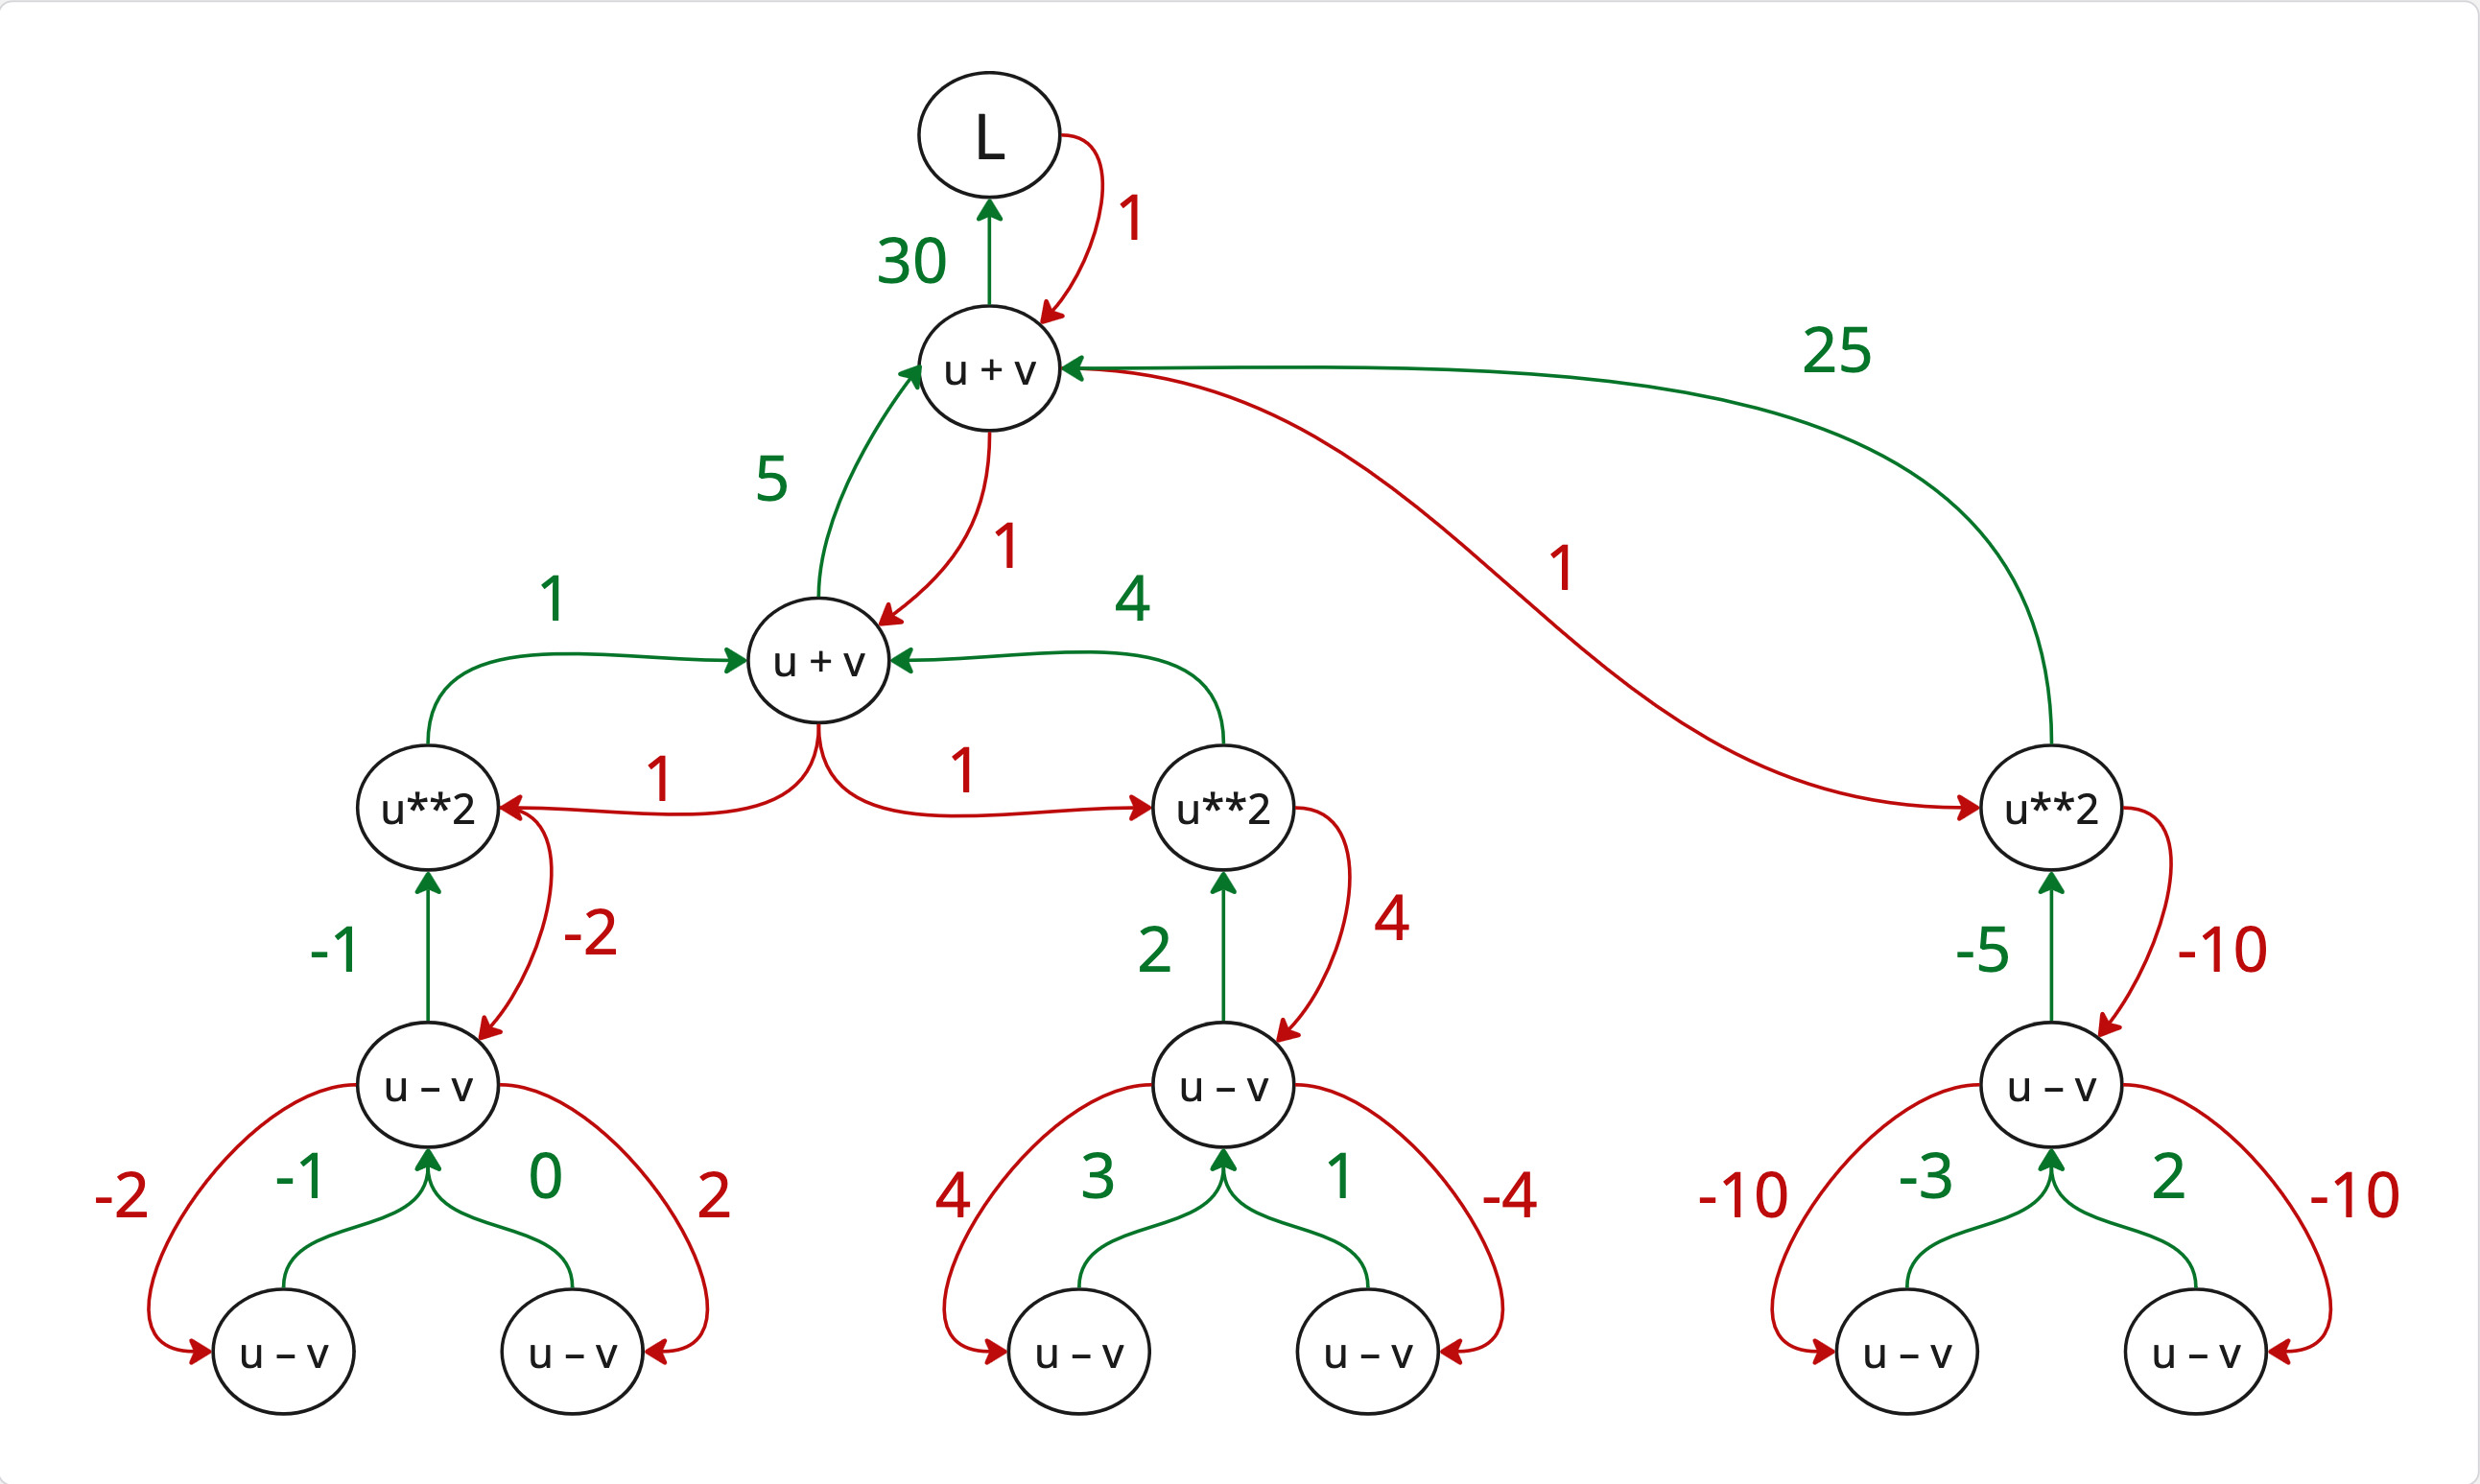!

Автоматическое дифференцирование - это способ точно вычислять производные программ (не только формул) за время, сравнимое с временем прямого расчёта. Важно отличать его от:

1. численного дифференцирования (конечные разности и конечных элементов) - просто приближает производные и чувствительно к шагу/шуму;

2. символьного (как в CAS) - оперирует формулами, но плохо справляется с произвольным кодом (циклы, ветвления, таблицы).

Идея автодифа: представить вычисление как граф из примитивных операций (сложение, умножение, sin, exp, matmul), для каждой операции знать локальные производные и собрать глобальные градиенты по [Chain Rule](https://en.wikipedia.org/wiki/Chain_rule).

Перед тем, как считать производную,

In [32]:
x = torch.Tensor([-1.0, 3.0, -3.0]).requires_grad_(True)
c = torch.Tensor([0.0, 1.0, 2.0])
L = torch.sum((x - c)**2)
print(x)
print(c)
print(L)

tensor([-1.,  3., -3.], requires_grad=True)
tensor([0., 1., 2.])
tensor(30., grad_fn=<SumBackward0>)


Считаем градиент переменной `L` по параметрам `x`:

In [33]:
L.backward()

Градиент по `x`:

In [34]:
print(x.grad)

tensor([ -2.,   4., -10.])


Минимизируем `L` методом [градиентного спуска](https://en.wikipedia.org/wiki/Gradient_descent):

In [35]:
optimizer = torch.optim.SGD(params=[x], lr=0.1)

for _ in range(100):
    optimizer.zero_grad()
    L = torch.sum((x - c)**2)
    L.backward()
    optimizer.step()

L = torch.sum((x - c)**2)

print(L, x)

tensor(1.1369e-13, grad_fn=<SumBackward0>) tensor([-2.0370e-10,  1.0000e+00,  2.0000e+00], requires_grad=True)
